In [18]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [12]:
dataset_path = "/content/drive/MyDrive/SpiderVerse_Dataset/gwen_stacy/"

In [13]:
import glob
files = glob.glob(dataset_path + "/*.jpg")
print("The number of file is:",len(files))

The number of file is: 397


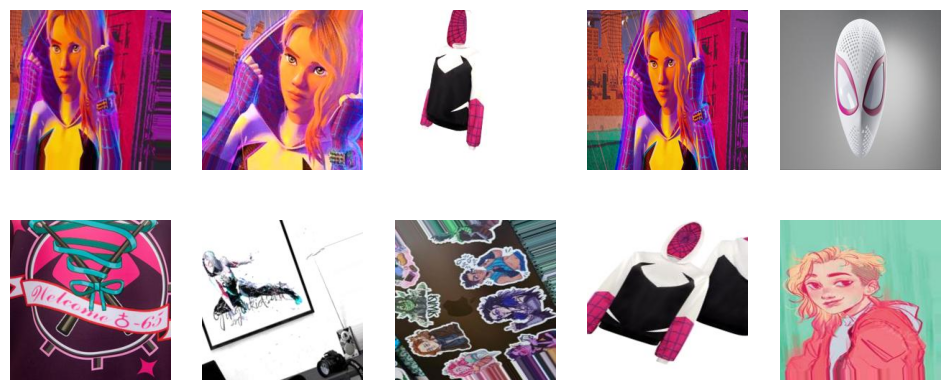

In [14]:
plt.figure(figsize= (12,5))

for i in range(10):
  img=cv2.imread(files[i])
  img=img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  plt.subplot(2,5,i+1)

  plt.imshow(img)
  plt.axis("off")

/tmp/ipykernel_1086/2181078108.py:11: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(),256,[0,256])


Text(0.5, 1.0, 'Histogram')

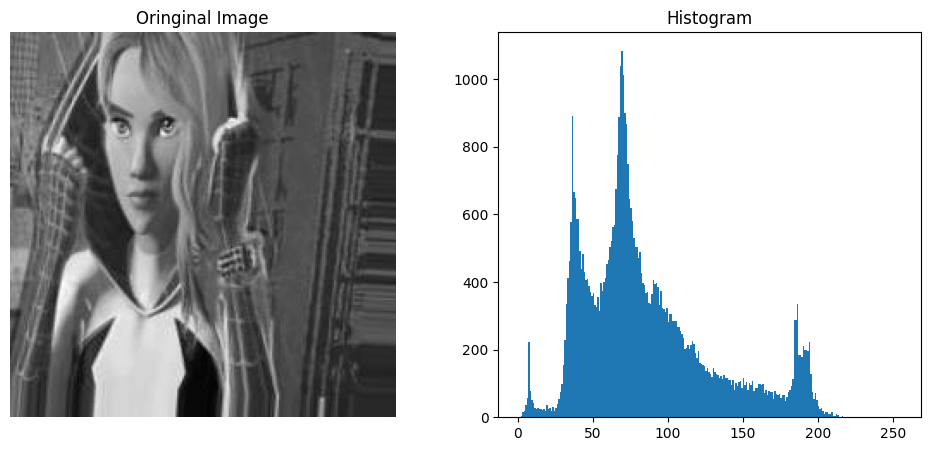

In [15]:
img = cv2.imread(files[0],0)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img,cmap="gray")
plt.title("Oringinal Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.hist(img.ravel(),256,[0,256])
plt.title("Histogram")

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

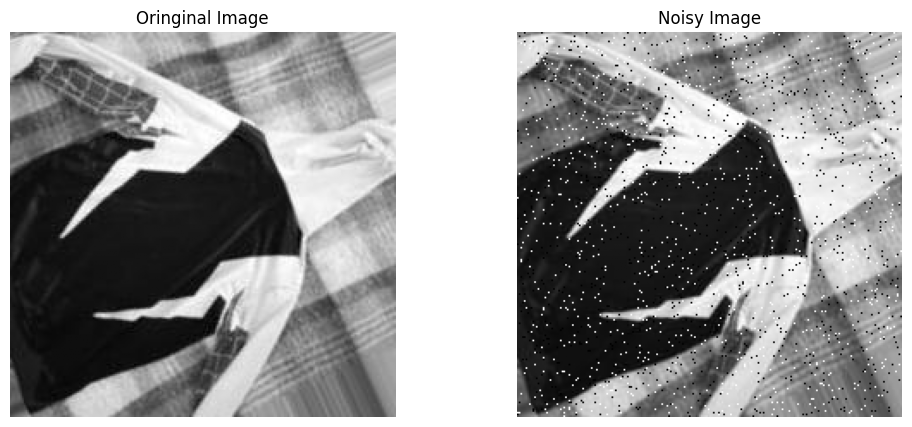

In [23]:
img = cv2.imread(files[10],0)

noisy = img.copy()

num_salt = 1000
x = np.random.randint(0,img.shape[0],num_salt)
y = np.random.randint(0,img.shape[1],num_salt)
noisy[x,y] = 255

num_papper = 1000
x = np.random.randint(0,img.shape[0],num_papper)
y = np.random.randint(0,img.shape[1],num_papper)

noisy[x,y] = 0

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img,cmap="gray")
plt.title("Oringinal Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(noisy,cmap="gray")
plt.title("Noisy Image")
plt.axis("off")

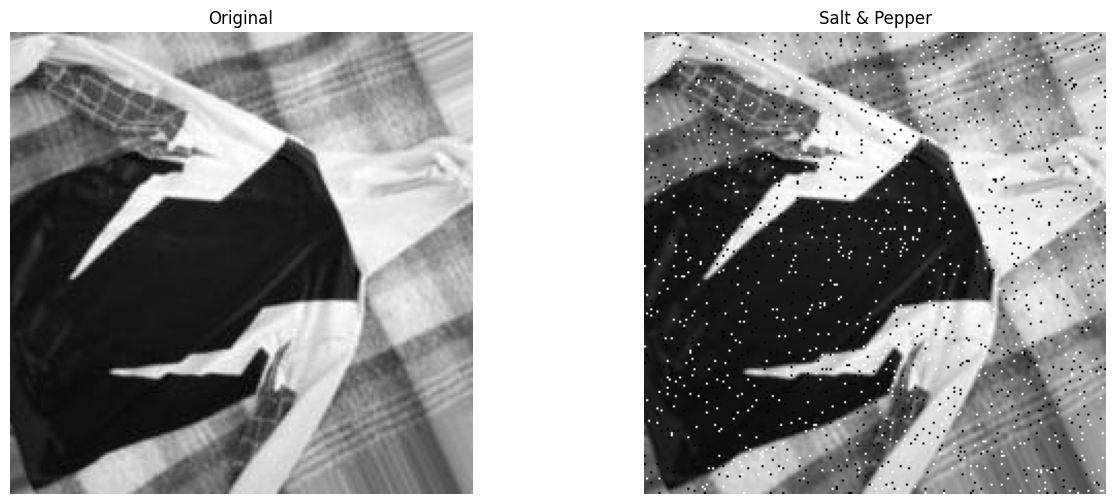

In [24]:
def add_salt_and_pepper_noise(image, salt_vs_pepper=0.5, amount=0.04):
    noisy = np.copy(image)
    total = int(amount * image.size)

    # Salt (white pixels)
    coords = [np.random.randint(0, i, int(total * salt_vs_pepper)) for i in image.shape]
    noisy[coords[0], coords[1]] = 255

    # Pepper (black pixels)
    coords = [np.random.randint(0, i, int(total * (1 - salt_vs_pepper))) for i in image.shape]
    noisy[coords[0], coords[1]] = 0

    return noisy

# Convert image
img_rgb = cv2.cvtColor(img if len(img.shape) == 3 else cv2.cvtColor(img, cv2.COLOR_GRAY2BGR), cv2.COLOR_BGR2RGB)
noisy_rgb = cv2.cvtColor(add_salt_and_pepper_noise(img), cv2.COLOR_BGR2RGB)

# Display
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, image, title in zip(axes, [img_rgb, noisy_rgb], ['Original', 'Salt & Pepper']):
    ax.imshow(image)
    ax.set_title(title)
    ax.axis('off')

plt.show()